# Taller 4.2 — Predicción de Transmisión del Dengue: Pipeline ML Completo
**Dataset:** DengAI — DrivenData  
**Objetivo:** Predecir `total_cases` a partir de variables climáticas usando regresión supervisada.

## 1. Carga y Análisis Exploratorio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)

# Carga de datos
train_features = pd.read_csv('dengue_features_train.csv')
train_labels   = pd.read_csv('dengue_labels_train.csv')
test_features  = pd.read_csv('dengue_features_test.csv')
submission_fmt = pd.read_csv('submission_format.csv')

print('Train features:', train_features.shape)
print('Train labels:  ', train_labels.shape)
print('Test features: ', test_features.shape)
print('Ciudades:', train_features['city'].unique())

Train features: (1456, 24)
Train labels:   (1456, 4)
Test features:  (416, 24)
Ciudades: ['sj' 'iq']


In [3]:
# Estructura general
train_features.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [4]:
# Estadísticas descriptivas de variables climáticas
climate_cols = [
    'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k',
    'reanalysis_dew_point_temp_k', 'reanalysis_relative_humidity_percent',
    'reanalysis_specific_humidity_g_per_kg', 'station_avg_temp_c',
    'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm'
]

train_features[climate_cols].describe().round(2)

,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_relative_humidity_percent,reanalysis_specific_humidity_g_per_kg,station_avg_temp_c,station_max_temp_c,station_min_temp_c,station_precip_mm
count,1443.00,1446.00,1446.00,1446.00,1446.00,1446.00,1413.00,1436.00,1442.00,1434.00
mean,45.76,298.70,299.23,295.25,82.16,16.75,27.19,32.45,22.10,39.33
std,43.72,1.36,1.26,1.53,7.15,1.54,1.29,1.96,1.57,47.46
min,0.00,294.64,294.89,289.64,57.79,11.72,21.40,26.70,14.70,0.00
25%,9.80,297.66,298.26,294.12,77.18,15.56,26.30,31.10,21.10,8.70
50%,38.34,298.65,299.29,295.64,80.30,17.09,27.41,32.80,22.20,23.85
75%,70.24,299.83,300.21,296.46,86.36,17.98,28.16,33.90,23.30,53.90
max,390.60,302.20,302.93,298.45,98.61,20.46,30.80,42.20,25.60,543.30


In [5]:
# Estadísticas descriptivas de total_cases
train_labels['total_cases'].describe().round(2)

count    1456.00
mean       24.68
std        43.60
min         0.00
25%         5.00
50%        12.00
75%        28.00
max       461.00
Name: total_cases, dtype: float64

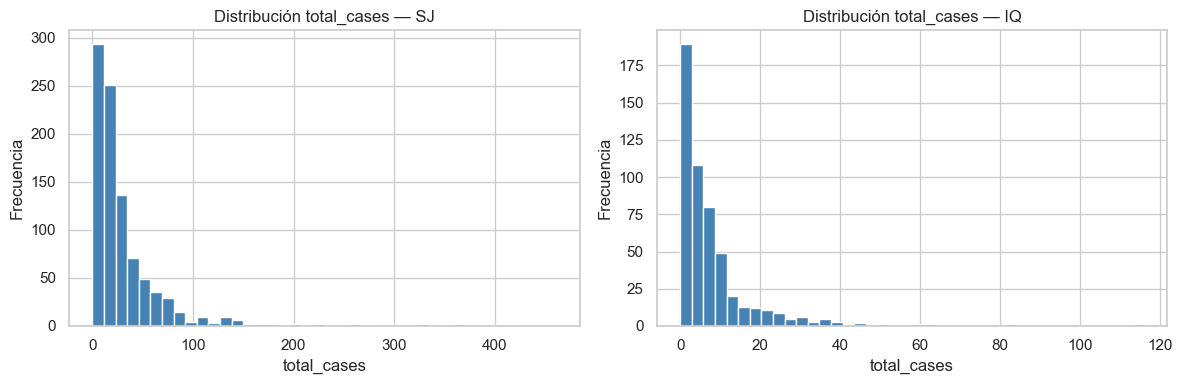

In [6]:
# Unir features + labels para EDA
train = train_features.merge(train_labels[['city','year','weekofyear','total_cases']],
                              on=['city','year','weekofyear'])

# Distribución de total_cases por ciudad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, city in zip(axes, ['sj', 'iq']):
    data = train[train['city'] == city]['total_cases']
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución total_cases — {city.upper()}')
    ax.set_xlabel('total_cases')
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('dist_total_cases.png', dpi=100)
plt.show()

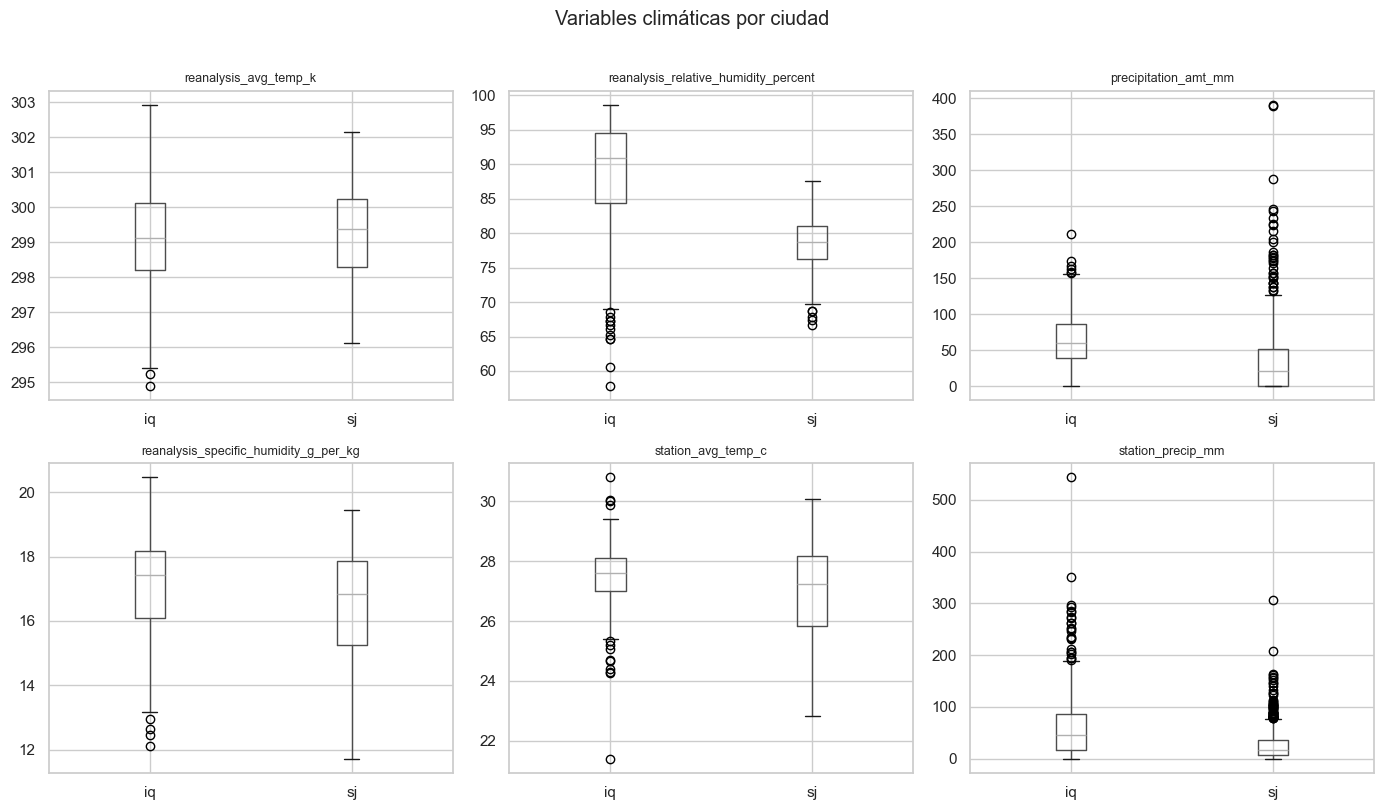

In [7]:
# Boxplots de variables climáticas seleccionadas por ciudad
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
box_vars = [
    'reanalysis_avg_temp_k', 'reanalysis_relative_humidity_percent',
    'precipitation_amt_mm', 'reanalysis_specific_humidity_g_per_kg',
    'station_avg_temp_c', 'station_precip_mm'
]
for ax, col in zip(axes.flat, box_vars):
    train.boxplot(column=col, by='city', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Variables climáticas por ciudad', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_clima.png', dpi=100)
plt.show()

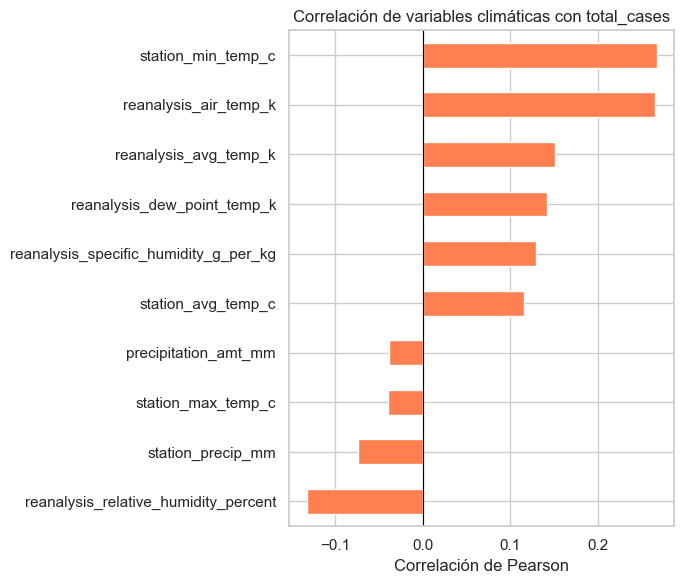

                                       total_cases
reanalysis_relative_humidity_percent        -0.132
station_precip_mm                           -0.074
station_max_temp_c                          -0.039
precipitation_amt_mm                        -0.039
station_avg_temp_c                           0.116
reanalysis_specific_humidity_g_per_kg        0.130
reanalysis_dew_point_temp_k                  0.143
reanalysis_avg_temp_k                        0.152
reanalysis_air_temp_k                        0.265
station_min_temp_c                           0.267


In [8]:
# Correlaciones con total_cases
corr_cols = climate_cols + ['total_cases']
corr = train[corr_cols].corr()[['total_cases']].drop('total_cases').sort_values('total_cases')

fig, ax = plt.subplots(figsize=(7, 6))
corr['total_cases'].plot(kind='barh', ax=ax, color='coral')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables climáticas con total_cases')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=100)
plt.show()

print(corr.round(3))

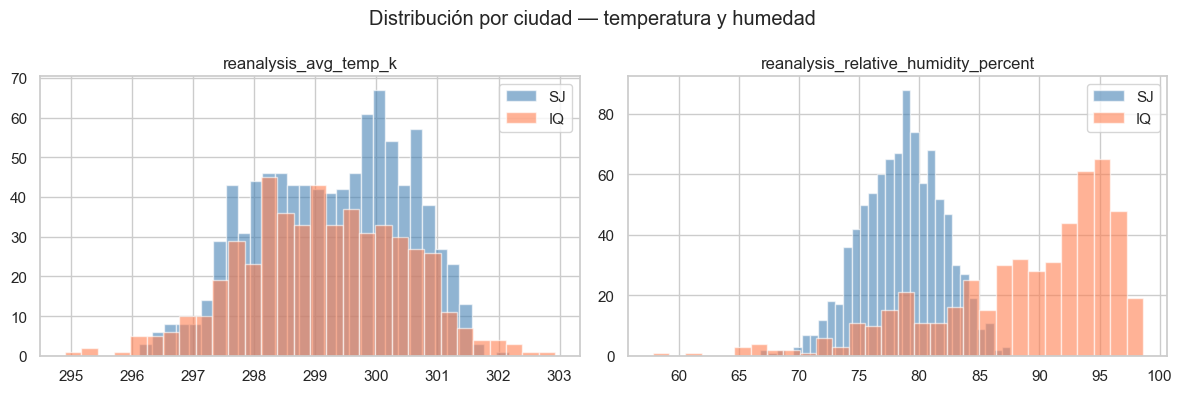

In [9]:
# Comparación de distribuciones entre ciudades
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['reanalysis_avg_temp_k', 'reanalysis_relative_humidity_percent']):
    for city, color in zip(['sj','iq'], ['steelblue','coral']):
        train[train['city']==city][col].hist(ax=ax, bins=30, alpha=0.6, label=city.upper(), color=color)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Distribución por ciudad — temperatura y humedad')
plt.tight_layout()
plt.savefig('dist_por_ciudad.png', dpi=100)
plt.show()

## 2. Preprocesamiento y Selección de Variables

**Valores faltantes:** Se aplica interpolación lineal por ciudad porque los datos son series temporales semanales; rellenar con la media global ignoraría la tendencia temporal. Se completa con forward/backward fill para valores en los extremos.

**Features seleccionadas:** Se escogen variables de temperatura, humedad y precipitación basadas en correlación y relevancia epidemiológica documentada para dengue (temperatura y humedad favorecen la reproducción del mosquito *Aedes aegypti*).

**Normalización:** Se aplica `StandardScaler` para que Random Forest no sea afectado por diferencias de escala entre variables (Kelvin vs mm vs %).

In [10]:
FEATURES = [
    'reanalysis_avg_temp_k',
    'reanalysis_dew_point_temp_k',
    'reanalysis_relative_humidity_percent',
    'reanalysis_specific_humidity_g_per_kg',
    'reanalysis_tdtr_k',
    'precipitation_amt_mm',
    'reanalysis_precip_amt_kg_per_m2',
    'station_avg_temp_c',
    'station_max_temp_c',
    'station_min_temp_c',
    'station_precip_mm',
    'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw'
]

print('Valores faltantes por variable (train):')
print(train[FEATURES].isnull().sum())

Valores faltantes por variable (train):
reanalysis_avg_temp_k                     10
reanalysis_dew_point_temp_k               10
reanalysis_relative_humidity_percent      10
reanalysis_specific_humidity_g_per_kg     10
reanalysis_tdtr_k                         10
precipitation_amt_mm                      13
reanalysis_precip_amt_kg_per_m2           10
station_avg_temp_c                        43
station_max_temp_c                        20
station_min_temp_c                        14
station_precip_mm                         22
ndvi_ne                                  194
ndvi_nw                                   52
ndvi_se                                   22
ndvi_sw                                   22
dtype: int64


In [11]:
def preprocess(df, features, fit_scaler=None):
    """
    Imputa valores faltantes por interpolación lineal (por ciudad)
    y escala con StandardScaler.
    Si fit_scaler es None, ajusta y devuelve el scaler.
    Si fit_scaler es un scaler ya ajustado, solo transforma.
    """
    df = df.copy()
    # Interpolación por ciudad
    for city in df['city'].unique():
        mask = df['city'] == city
        df.loc[mask, features] = (
            df.loc[mask, features]
            .interpolate(method='linear', limit_direction='both')
        )
    # Por si quedan NaN en los bordes
    df[features] = df[features].fillna(df[features].median())

    X = df[features].values
    if fit_scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        return X_scaled, scaler
    else:
        return fit_scaler.transform(X)

X_train, scaler = preprocess(train, FEATURES)
y_train = train['total_cases'].values

print('X_train shape:', X_train.shape)
print('NaN en X_train:', np.isnan(X_train).sum())

X_train shape: (1456, 15)
NaN en X_train: 0


## 3. Entrenamiento del Modelo

**Modelo elegido: Random Forest Regressor**  
Justificación: la distribución de `total_cases` es fuertemente sesgada a la derecha (muchas semanas con pocos casos, algunas con brotes extremos). Random Forest es robusto a outliers y captura relaciones no lineales entre clima y casos, a diferencia de la Regresión Lineal que asume linealidad y distribución normal de residuos.

In [12]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print('Modelo entrenado — hiperparámetros:')
print(f'  n_estimators  : {model.n_estimators}')
print(f'  max_depth     : {model.max_depth}')
print(f'  min_samples_leaf: {model.min_samples_leaf}')
print(f'  random_state  : {model.random_state}')

Modelo entrenado — hiperparámetros:
  n_estimators  : 200
  max_depth     : 10
  min_samples_leaf: 5
  random_state  : 42


## 4. Validación Interna: Cross-Validation (k=5)

In [13]:
kf = KFold(n_splits=5, shuffle=False)  # shuffle=False preserva orden temporal

mae_scores  = []
rmse_scores = []

fold_model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    fold_model.fit(X_tr, y_tr)
    y_pred = fold_model.predict(X_val)
    y_pred = np.maximum(y_pred, 0)  # casos no pueden ser negativos

    mae  = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f'Pliegue {fold} — MAE: {mae:.2f}  |  RMSE: {rmse:.2f}')

print(f'\nMAE  promedio: {np.mean(mae_scores):.2f}  ± {np.std(mae_scores):.2f}')
print(f'RMSE promedio: {np.mean(rmse_scores):.2f}  ± {np.std(rmse_scores):.2f}')

Pliegue 1 — MAE: 38.64  |  RMSE: 80.90
Pliegue 2 — MAE: 26.22  |  RMSE: 42.45
Pliegue 3 — MAE: 33.19  |  RMSE: 39.06
Pliegue 4 — MAE: 11.04  |  RMSE: 17.94
Pliegue 5 — MAE: 7.45  |  RMSE: 13.65

MAE  promedio: 23.31  ± 12.19
RMSE promedio: 38.80  ± 23.89


In [14]:
# Tabla métricas por pliegue
cv_table = pd.DataFrame({
    'Pliegue': range(1, 6),
    'MAE':  [round(v, 2) for v in mae_scores],
    'RMSE': [round(v, 2) for v in rmse_scores]
})
cv_table.loc[len(cv_table)] = ['Promedio', round(np.mean(mae_scores),2), round(np.mean(rmse_scores),2)]
print(cv_table.to_string(index=False))

 Pliegue   MAE  RMSE
       1 38.64 80.90
       2 26.22 42.45
       3 33.19 39.06
       4 11.04 17.94
       5  7.45 13.65
Promedio 23.31 38.80


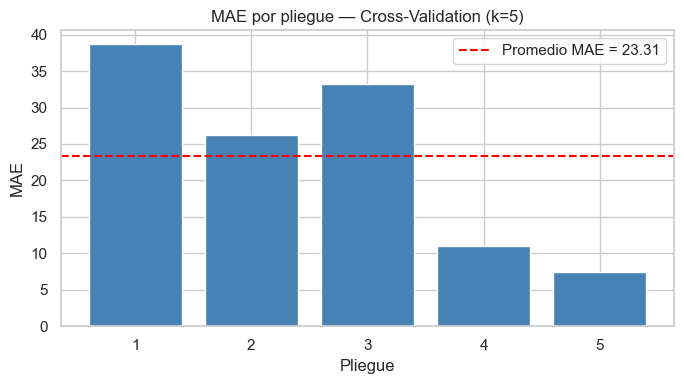


Variabilidad entre pliegues: std = 12.19
El modelo es consistente entre pliegues si el std es bajo respecto al promedio.


In [15]:
# Gráfico MAE por pliegue
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), mae_scores, color='steelblue', edgecolor='white')
ax.axhline(np.mean(mae_scores), color='red', linestyle='--', label=f'Promedio MAE = {np.mean(mae_scores):.2f}')
ax.set_xlabel('Pliegue')
ax.set_ylabel('MAE')
ax.set_title('MAE por pliegue — Cross-Validation (k=5)')
ax.legend()
plt.tight_layout()
plt.savefig('mae_por_pliegue.png', dpi=100)
plt.show()

print(f'\nVariabilidad entre pliegues: std = {np.std(mae_scores):.2f}')
print('El modelo es consistente entre pliegues si el std es bajo respecto al promedio.')

Error por ciudad (entrenamiento):
        MAE    STD
city              
iq     4.56   6.45
sj    17.93  25.20


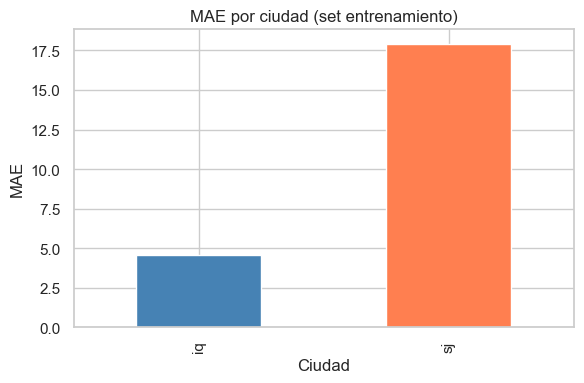

In [16]:
# Error por ciudad (usando todo el set de entrenamiento)
y_pred_all = np.maximum(model.predict(X_train), 0)
train_eval = train[['city']].copy()
train_eval['actual']    = y_train
train_eval['predicted'] = y_pred_all
train_eval['abs_error'] = np.abs(train_eval['actual'] - train_eval['predicted'])

error_ciudad = train_eval.groupby('city')['abs_error'].agg(['mean','std']).round(2)
error_ciudad.columns = ['MAE', 'STD']
print('Error por ciudad (entrenamiento):')
print(error_ciudad)

fig, ax = plt.subplots(figsize=(6, 4))
error_ciudad['MAE'].plot(kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='white')
ax.set_title('MAE por ciudad (set entrenamiento)')
ax.set_ylabel('MAE')
ax.set_xlabel('Ciudad')
plt.tight_layout()
plt.savefig('error_por_ciudad.png', dpi=100)
plt.show()

## 5. Generación del Archivo de Predicción (submission)

In [17]:
# Aplicar exactamente el mismo preprocesamiento al set de test
X_test = preprocess(test_features, FEATURES, fit_scaler=scaler)

print('X_test shape:', X_test.shape)
print('NaN en X_test:', np.isnan(X_test).sum())

# Predicción
y_test_pred = np.maximum(model.predict(X_test), 0)
y_test_pred = np.round(y_test_pred).astype(int)

# Generar submission.csv con el formato exigido
submission = submission_fmt[['city','year','weekofyear']].copy()
submission['total_cases'] = y_test_pred

# Validación del archivo
assert submission.shape == (416, 4), 'Dimensiones incorrectas'
assert submission['total_cases'].isnull().sum() == 0, 'Hay NaN en total_cases'
assert submission['total_cases'].dtype in [int, np.int32, np.int64], 'No es entero'
assert list(submission.columns) == ['city','year','weekofyear','total_cases'], 'Columnas incorrectas'

submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv generado correctamente')
print(submission.head(10))

X_test shape: (416, 15)
NaN en X_test: 0

submission.csv generado correctamente
  city  year  weekofyear  total_cases
0   sj  2008          18           14
1   sj  2008          19           14
2   sj  2008          20           15
3   sj  2008          21           30
4   sj  2008          22           27
5   sj  2008          23           31
6   sj  2008          24           23
7   sj  2008          25           33
8   sj  2008          26           30
9   sj  2008          27           33


In [18]:
# Validación visual del archivo
sub_check = pd.read_csv('submission.csv')
print('Shape:', sub_check.shape)
print('Columnas:', list(sub_check.columns))
print('NaN:', sub_check.isnull().sum().sum())
print('Ciudades:', sub_check['city'].unique())
print('Rango total_cases:', sub_check['total_cases'].min(), '-', sub_check['total_cases'].max())
print('\nPrimeras filas:')
print(sub_check.head())

Shape: (416, 4)
Columnas: ['city', 'year', 'weekofyear', 'total_cases']
NaN: 0
Ciudades: ['sj' 'iq']
Rango total_cases: 2 - 112

Primeras filas:
  city  year  weekofyear  total_cases
0   sj  2008          18           14
1   sj  2008          19           14
2   sj  2008          20           15
3   sj  2008          21           30
4   sj  2008          22           27


## 6. Envío a DrivenData y Análisis Externo

**Pasos para el envío:**
1. Crear cuenta en [DrivenData](https://www.drivendata.org/)
2. Ir al concurso *DengAI: Predicting Disease Spread*
3. Subir el archivo `submission.csv`
4. Registrar el MAE obtenido en la plataforma

*(Completar la celda siguiente con el score real obtenido después del envío)*

In [19]:
# Registrar scores después del envío a DrivenData
mae_interno  = round(np.mean(mae_scores), 2)   # MAE promedio CV
mae_externo  = 26.9207  # <-- Reemplazar con el MAE obtenido en DrivenData

print(f'MAE interno (CV promedio) : {mae_interno}')
print(f'MAE externo (DrivenData)  : {mae_externo if mae_externo else "Pendiente de envío"}')

MAE interno (CV promedio) : 23.31
MAE externo (DrivenData)  : 26.9207


## 7. Análisis Comparativo: Validación Interna vs Score Externo

In [20]:
# Tabla comparativa (completar mae_externo con el valor real de DrivenData)
mae_externo_ejemplo = mae_externo if mae_externo else '—'
diferencia = round(float(mae_externo) - mae_interno, 2) if mae_externo else '—'

comp_table = pd.DataFrame({
    'Métrica': ['MAE'],
    'Validación Interna (CV)': [mae_interno],
    'Score DrivenData (externo)': [mae_externo_ejemplo],
    'Diferencia': [diferencia]
})
print(comp_table.to_string(index=False))

Métrica  Validación Interna (CV)  Score DrivenData (externo)  Diferencia
    MAE                    23.31                     26.9207        3.61
